# Dataset

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading

In [2]:
import yaml
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
CONFIG_PATH = PROJECT_ROOT / "config" / "config.yaml"

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

raw_path = PROJECT_ROOT / config["data"]["raw_path"]

In [3]:
# using only 1,000,000 instances
n_total = 24_386_900
sample_n = 1_000_000
skip = sorted(pd.Series(range(1, n_total)).sample(n_total - sample_n, 
    random_state=42).tolist())

In [26]:
df_sample = pd.read_csv(raw_path, skiprows=skip)
df_sample.head()

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No
1,0,0,2002,9,12,06:50,$52.52,Swipe Transaction,4060646732831064559,La Verne,CA,91750.0,5411,NaN,No
2,0,0,2002,9,15,13:54,$81.35,Swipe Transaction,-5904116920141006298,Diamond Bar,CA,91765.0,5719,NaN,No
3,0,0,2002,9,22,09:37,$82.90,Swipe Transaction,3952145593743244256,La Verne,CA,91750.0,7538,NaN,No
4,0,0,2002,10,14,06:12,$1049.82,Swipe Transaction,-2187837027406294082,San Diego,CA,92123.0,3058,NaN,No


## Cleaning

In [27]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   User            1000000 non-null  int64  
 1   Card            1000000 non-null  int64  
 2   Year            1000000 non-null  int64  
 3   Month           1000000 non-null  int64  
 4   Day             1000000 non-null  int64  
 5   Time            1000000 non-null  object 
 6   Amount          1000000 non-null  object 
 7   Use Chip        1000000 non-null  object 
 8   Merchant Name   1000000 non-null  int64  
 9   Merchant City   1000000 non-null  object 
 10  Merchant State  888634 non-null   object 
 11  Zip             882300 non-null   float64
 12  MCC             1000000 non-null  int64  
 13  Errors?         15853 non-null    object 
 14  Is Fraud?       1000000 non-null  object 
dtypes: float64(1), int64(7), object(7)
memory usage: 114.4+ MB


In [28]:
# Creating timestamp
df_sample["timestamp"] = pd.to_datetime(
    df_sample["Year"].astype(str) + "-" +
    df_sample["Month"].astype(str).str.zfill(2) + "-" +
    df_sample["Day"].astype(str).str.zfill(2) + " " +
    df_sample["Time"].astype(str),
    format="%Y-%m-%d %H:%M"
)

df_sample = df_sample.drop(columns=["Year", "Month", "Day", "Time"])

In [29]:
# Updating column names
df_sample = df_sample.rename(columns={'User':'user','Card':'card','Amount':'amount','Use Chip':'use_chip', 'Merchant Name':'merchant_name', 
                                      'Merchant City': 'merchant_city', 'Merchant State':'merchant_state', 'Zip':'zip', 'MCC':'mcc', 
                                      'Errors?':'errors', 'Is Fraud?':'is_fraud'})

In [30]:
# Converting amount from str to float
df_sample["amount"] = df_sample["amount"].astype(str)
df_sample["amount"] = df_sample["amount"].str.replace("$", "", regex=False).str.replace(",", "", regex=False)
df_sample["amount"] = df_sample["amount"].astype(float)

In [31]:
df_sample["is_fraud"] = (df_sample["is_fraud"] == "Yes").astype("int8")   # 1- fraud, 0- not fraud

# Refund flag (-ve amount = refund)
df_sample["is_refund"] = (df_sample["amount"] < 0).astype("int8")

In [32]:
# Errors
df_sample["has_error"] = df_sample["errors"].notna().astype("int8")  # 1- error, 0- no error
df_sample["errors"] = df_sample["errors"].fillna("None")

In [33]:
# Missing location and zip
df_sample["merchant_state"] = df_sample["merchant_state"].fillna("ONLINE")
df_sample["zip"] = df_sample["zip"].fillna(0).astype("int32")

# Simplifying use_chip objects: "swipe", "chip", "online"
df_sample["use_chip"] = df_sample["use_chip"].str.lower().str.replace(" transaction", "", regex=False)

df_sample.head()

,user,card,amount,use_chip,merchant_name,merchant_city,merchant_state,zip,mcc,errors,is_fraud,timestamp,is_refund,has_error
0,0,0,104.71,swipe,5817218446178736267,La Verne,CA,91750,5912,None,0,2002-09-03 06:23:00,0,0
1,0,0,52.52,swipe,4060646732831064559,La Verne,CA,91750,5411,None,0,2002-09-12 06:50:00,0,0
2,0,0,81.35,swipe,-5904116920141006298,Diamond Bar,CA,91765,5719,None,0,2002-09-15 13:54:00,0,0
3,0,0,82.90,swipe,3952145593743244256,La Verne,CA,91750,7538,None,0,2002-09-22 09:37:00,0,0
4,0,0,1049.82,swipe,-2187837027406294082,San Diego,CA,92123,3058,None,0,2002-10-14 06:12:00,0,0


## Summary

In [34]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   user            1000000 non-null  int64         
 1   card            1000000 non-null  int64         
 2   amount          1000000 non-null  float64       
 3   use_chip        1000000 non-null  object        
 4   merchant_name   1000000 non-null  int64         
 5   merchant_city   1000000 non-null  object        
 6   merchant_state  1000000 non-null  object        
 7   zip             1000000 non-null  int32         
 8   mcc             1000000 non-null  int64         
 9   errors          1000000 non-null  object        
 10  is_fraud        1000000 non-null  int8          
 11  timestamp       1000000 non-null  datetime64[ns]
 12  is_refund       1000000 non-null  int8          
 13  has_error       1000000 non-null  int8          
dtypes: datetime64[ns](1

In [35]:
df_sample.describe()

,user,card,amount,merchant_name,zip,mcc,is_fraud,timestamp,is_refund,has_error
count,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000,1000000.000000,1000000.000000
mean,1000.957495,1.352088,43.838720,-4.769748e+17,44929.434823,5561.607653,0.001278,2012-06-15 02:36:51.801239808,0.050694,0.015853
min,0.000000,0.000000,-500.000000,-9.222899e+18,0.000000,1711.000000,0.000000,1991-03-01 18:23:00,0.000000,0.000000
25%,510.000000,0.000000,9.180000,-4.500543e+18,16218.000000,5300.000000,0.000000,2008-12-24 10:28:15,0.000000,0.000000
50%,1006.000000,1.000000,30.130000,-7.820165e+17,40509.000000,5499.000000,0.000000,2013-01-11 07:39:00,0.000000,0.000000
75%,1477.000000,2.000000,65.000000,3.189517e+18,75227.000000,5812.000000,0.000000,2016-08-28 02:46:00,0.000000,0.000000
max,1999.000000,8.000000,4138.950000,9.222877e+18,99925.000000,9402.000000,1.000000,2020-02-28 23:53:00,1.000000,1.000000
std,569.906089,1.406522,82.809451,4.759144e+18,32152.205837,879.848374,0.035726,NaN,0.219372,0.124907


#### Conclusion :-
##### 1. Number of Users: 2000 (0 to 1999)
##### 2. Max. Cards per User: 9 (0 to 8)
##### 3. MCC: 1711 to 9402
##### 4. Years: 1991 to 2020

In [36]:
df_sample.describe(include=['object'])

,use_chip,merchant_city,merchant_state,errors
count,1000000,1000000,1000000,1000000
unique,3,9514,180,20
top,swipe,ONLINE,ONLINE,None
freq,631114,111366,111366,984147


In [38]:
# Refund amounts
df_sample[df_sample["is_refund"] == 1]["amount"].describe()

count    50694.000000
mean      -102.320633
std         84.625377
min       -500.000000
25%        -93.000000
50%        -79.000000
75%        -64.000000
max         -0.010000
Name: amount, dtype: float64

# Exploratory Data Analysis

## Class Imbalance

In [68]:
# Fraud and Non-fraud rates
fraud_counts = df_sample["is_fraud"].value_counts()
fraud_rate = df_sample["is_fraud"].mean()

print(f"Non-Fraud:  {fraud_counts[0]:,}  ({100 - fraud_rate * 100:.2f}%)")
print(f"Fraud:      {fraud_counts[1]:,}  ({fraud_rate * 100:.2f}%)")
print(f"Ratio:      {int(fraud_counts[0] / fraud_counts[1])}:1  (non-fraud to fraud)")
print(f"scale_pos_weight estimate: {int(fraud_counts[0] / fraud_counts[1])}\n")

Non-Fraud:  998,722  (99.87%)
Fraud:      1,278  (0.13%)
Ratio:      781:1  (non-fraud to fraud)
scale_pos_weight estimate: 781



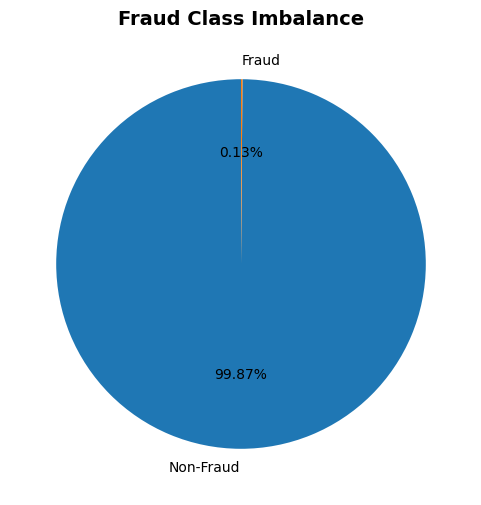

In [69]:
# Fraud Class Imbalance Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    fraud_counts,
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Fraud Class Imbalance", fontsize=14, fontweight="bold")
plt.show()

#### Conclusion :-
##### Only a very small percentage of all transactions is Fraud (0.13%) 

## Type of Transaction

use_chip
swipe     0.631114
chip      0.257826
online    0.111060
Name: proportion, dtype: float64


<Axes: xlabel='timestamp'>

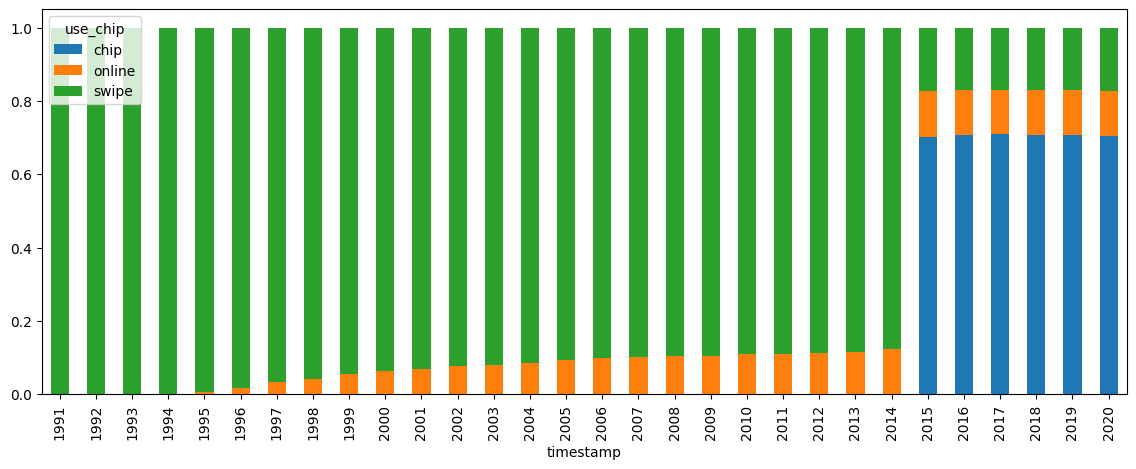

In [39]:
# use_chip bar graph by type
print(df_sample["use_chip"].value_counts(normalize=True))
df_sample.groupby(df_sample["timestamp"].dt.year)["use_chip"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True, figsize=(14,5))

#### Conclusion :-
##### 1. From 1991 to 2014, **"swipe"** method dominated, before being majorly reduced.
##### 2. In 2015, **"chips"** method was introduced, which became the most used method till 2020.
##### 3. **"online"** method has gradually increased over the years but has remained the least used method in every year.


In [76]:
# Fraud rate by transaction type
fraud_stats = df_sample.groupby("use_chip")["is_fraud"].agg(
    total="count",
    fraud_count="sum",
    fraud_rate="mean"
).round(4)

print(fraud_stats)

           total  fraud_count  fraud_rate
use_chip                                 
chip      257826          223      0.0009
online    111060          771      0.0069
swipe     631114          284      0.0004


<Axes: title={'center': 'Fraud Rate by Transaction Method'}, xlabel='Transaction Method', ylabel='Fraud Rate'>

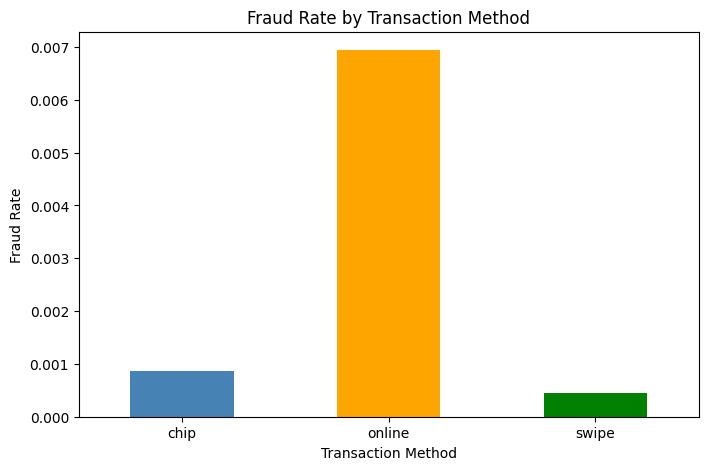

In [77]:
# Fraud rate visualized
df_sample.groupby("use_chip")["is_fraud"].mean().plot(
    kind="bar", 
    figsize=(8, 5), 
    title="Fraud Rate by Transaction Method",
    ylabel="Fraud Rate",
    xlabel="Transaction Method",
    color=["steelblue", "orange", "green"],
    rot=0
)

#### Conclusion :-
##### **"online"** transactions are most likely to be Fraud by a large margin

### Type of Error

In [65]:
# Fraud rate by error type
error_fraud = df_sample[df_sample["errors"] != "None"].groupby("errors")["is_fraud"]
error_fraud = error_fraud.agg(total="count", fraud_count="sum", fraud_rate="mean")
error_fraud = error_fraud.sort_values("fraud_rate", ascending=False).round(4)

print(error_fraud)

                                        total  fraud_count  fraud_rate
errors                                                                
Bad CVV,                                  446           13      0.0291
Bad Expiration,                           410            8      0.0195
Bad Card Number,                          559            4      0.0072
Bad PIN,                                 2369           12      0.0051
Insufficient Balance,                    9917           16      0.0016
Technical Glitch,                        2011            3      0.0015
Bad CVV,Insufficient Balance,               4            0      0.0000
Bad CVV,Technical Glitch,                   1            0      0.0000
Bad Card Number,Insufficient Balance,       5            0      0.0000
Bad Card Number,Bad Expiration,             2            0      0.0000
Bad Card Number,Bad CVV,                    6            0      0.0000
Bad Expiration,Insufficient Balance,        6            0      0.0000
Bad Ex

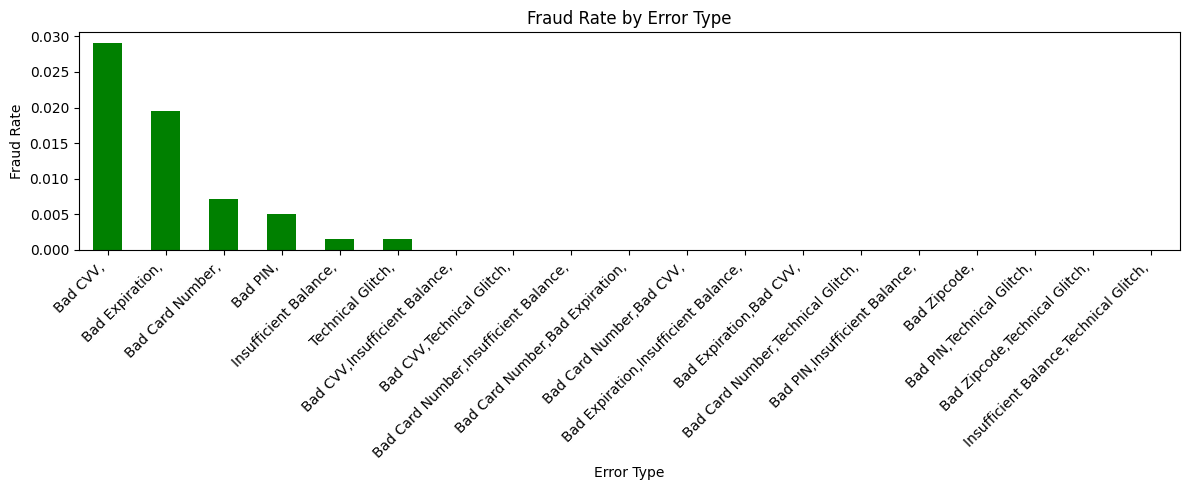

In [75]:
# Fraud rate by error bar graph
error_fraud["fraud_rate"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Fraud Rate by Error Type",
    ylabel="Fraud Rate",
    xlabel="Error Type",
    color="green",
    rot=45
)
plt.xticks(ha="right")
plt.tight_layout()
plt.show()

#### Conclusion :-
##### 1. **"Bad CVV", "Bad Expiration", "Bad Card Number", and "Bad PIN"** are some of the Errors that are most likely to be Fraud.
##### 2. Multiple Error types are least likely to be Fraud.